# %% [markdown]

 # Dynamic loss vs heat artifacts — findings, actions, and next steps

 This notebook summarizes:
 1) Findings from recent W&B runs (dynamic loss vs MSE, with/without caps)
 2) Actions taken in the codebase
 3) Suggested next experiments and diagnostics

 It also generates shareable figures.

# %% [markdown]

 ## Setup

In [ ]:
# %%

import math
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import wandb

In [ ]:
# %%

project = "ocean_emulators/default"

run_ids = {
    "train_dynamic_uncapped": "esgwyakp",
    "train_mse": "xp6cynwq",
    "eval_dynamic_uncapped": "9978odzx",
    "eval_mse": "63arypz3",
    "eval_cap_100": "mcfd40wy",
    "eval_cap_50": "wmaz39g9",
    "eval_cap_20": "uw49dzuq",
}

In [ ]:
# %%

try:
    api = wandb.Api()
    _ = api.runs(project, per_page=1)
except Exception as exc:
    raise RuntimeError(
        "W&B login required. Run `wandb login` or set WANDB_API_KEY."
    ) from exc


def get_run(run_id: str):
    return api.run(f"{project}/{run_id}")


def extract_loss_scales(run):
    return {
        k.split("/")[-1].removesuffix("_loss_scale"): float(v)
        for k, v in run.summary.items()
        if k.startswith("train/loss_scale/channel/") and isinstance(v, (int, float))
    }


def extract_grad(run, var_prefix: str):
    prefix = f"inference/mean/weighted_grad_mag_percent_diff/{var_prefix}_"
    out = {}
    for k, v in run.summary.items():
        if k.startswith(prefix) and isinstance(v, (int, float)):
            name = k[len(prefix) :]
            out[int(name)] = float(v)
    return out


def extract_ohc_metrics(run):
    keys = [
        "inference/mean/weighted_rmse/ocean_heat_content",
        "inference/mean_norm/weighted_rmse/ocean_heat_content",
        "inference/time_mean/rmse/ocean_heat_content",
        "inference/mean/weighted_grad_mag_percent_diff/ocean_heat_content",
        "inference/mean/weighted_bias/ocean_heat_content",
    ]
    return {k: run.summary.get(k, np.nan) for k in keys}


@dataclass
class CorrResult:
    pearson: float
    spearman: float
    n: int


def spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    rx = x.argsort().argsort().astype(float)
    ry = y.argsort().argsort().astype(float)
    return float(np.corrcoef(rx, ry)[0, 1])


def corr_log_scale_vs_grad(loss_scales, grad_by_depth, var_prefix: str):
    xs, ys = [], []
    for depth, grad in grad_by_depth.items():
        key = f"{var_prefix}_{depth}"
        if key in loss_scales:
            xs.append(math.log10(loss_scales[key]))
            ys.append(grad)
    if len(xs) < 5:
        return None
    return CorrResult(
        pearson=float(np.corrcoef(xs, ys)[0, 1]),
        spearman=spearman(xs, ys),
        n=len(xs),
    )


def run_info(run):
    return {
        "id": run.id,
        "name": run.name,
        "created_at": run.created_at,
        "commit": getattr(run, "commit", None),
    }

# %% [markdown]

 ## Pull runs and summarize key metadata

In [ ]:
# %%

runs = {k: get_run(v) for k, v in run_ids.items()}
for k, run in runs.items():
    info = run_info(run)
    print(k, info)

train_dynamic_uncapped {'id': 'esgwyakp', 'name': '2026-01-16-samudra_om4_onedeg_dmse_fix', 'created_at': '2026-01-16T20:57:07Z', 'commit': 'd0a41a1955cfb3b22fb75db88096d813fbcee346'}
train_mse {'id': 'xp6cynwq', 'name': '2026-01-09-samudra_om4_onedeg_mse', 'created_at': '2026-01-09T23:40:56Z', 'commit': 'acf6786e1ad85c1679dabfa378db96d41b0e2c59'}
eval_dynamic_uncapped {'id': '9978odzx', 'name': '2026-01-16-samudra_om4_onedeg_dmse_fix_eval', 'created_at': '2026-01-17T16:42:35Z', 'commit': 'd0a41a1955cfb3b22fb75db88096d813fbcee346'}
eval_mse {'id': '63arypz3', 'name': '2026-01-09-samudra_om4_onedeg_mse_eval', 'created_at': '2026-01-10T18:58:56Z', 'commit': '37f4720e52c029906b364db627d21fa7b390fdbf'}
eval_cap_100 {'id': 'mcfd40wy', 'name': '2026-01-20-samudra_om4_onedeg_100_cap_eval', 'created_at': '2026-01-21T14:30:52Z', 'commit': 'aeff37368af32473ef59a741e7156518af6fbf70'}
eval_cap_50 {'id': 'wmaz39g9', 'name': '2026-01-30-samudra_om4_onedeg_50_cap_eval', 'created_at': '2026-01-30T17:0

# %% [markdown]

 ## Findings from W&B

 ### 1) Dynamic loss scales explode for deep thetao/so

In [ ]:
# %%

loss_scales = extract_loss_scales(runs["train_dynamic_uncapped"])
ratio = max(loss_scales.values()) / min(loss_scales.values())
print("dynamic uncapped scale ratio:", ratio)

thetao_scales = {int(k.split("_")[1]): v for k, v in loss_scales.items() if k.startswith("thetao_")}
so_scales = {int(k.split("_")[1]): v for k, v in loss_scales.items() if k.startswith("so_")}

dynamic uncapped scale ratio: 20088.762219836957


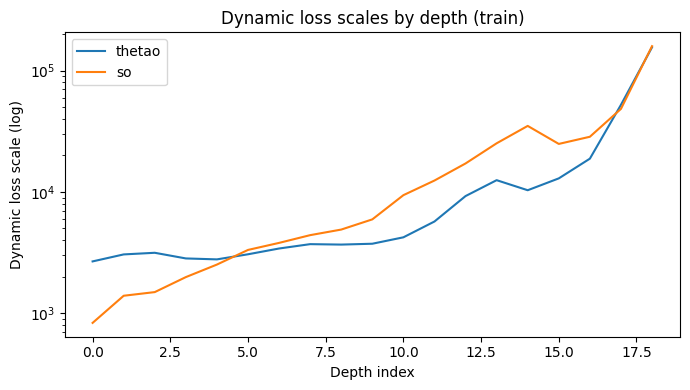

In [ ]:
# %%

plt.figure(figsize=(7, 4))
plt.semilogy(sorted(thetao_scales), [thetao_scales[k] for k in sorted(thetao_scales)], label="thetao")
plt.semilogy(sorted(so_scales), [so_scales[k] for k in sorted(so_scales)], label="so")
plt.xlabel("Depth index")
plt.ylabel("Dynamic loss scale (log)")
plt.title("Dynamic loss scales by depth (train)")
plt.legend()
plt.tight_layout()

# %% [markdown]

 ### 2) Long-rollout gradient artifacts concentrate in mid/deep thetao/so

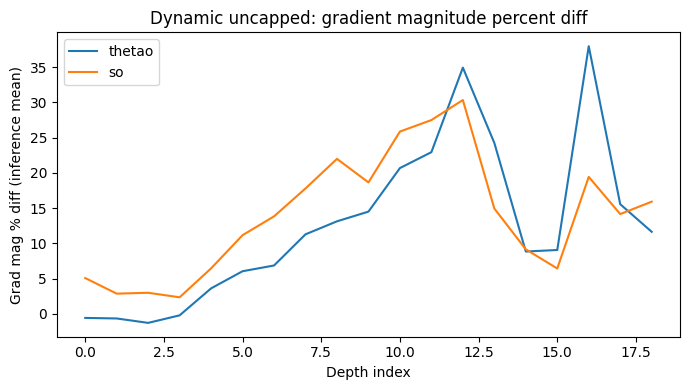

In [ ]:
# %%

grad_thetao_dyn = extract_grad(runs["eval_dynamic_uncapped"], "thetao")
grad_so_dyn = extract_grad(runs["eval_dynamic_uncapped"], "so")

plt.figure(figsize=(7, 4))
plt.plot(sorted(grad_thetao_dyn), [grad_thetao_dyn[k] for k in sorted(grad_thetao_dyn)], label="thetao")
plt.plot(sorted(grad_so_dyn), [grad_so_dyn[k] for k in sorted(grad_so_dyn)], label="so")
plt.xlabel("Depth index")
plt.ylabel("Grad mag % diff (inference mean)")
plt.title("Dynamic uncapped: gradient magnitude percent diff")
plt.legend()
plt.tight_layout()

# %% [markdown]

 ### 3) Correlation: dynamic scales vs gradient artifacts

In [ ]:
# %%

thetao_corr = corr_log_scale_vs_grad(loss_scales, grad_thetao_dyn, "thetao")
so_corr = corr_log_scale_vs_grad(loss_scales, grad_so_dyn, "so")
print("thetao corr:", thetao_corr)
print("so corr:", so_corr)

thetao corr: CorrResult(pearson=0.4140177473564229, spearman=0.736842105263158, n=19)
so corr: CorrResult(pearson=0.44408699782255623, spearman=0.5298245614035089, n=19)


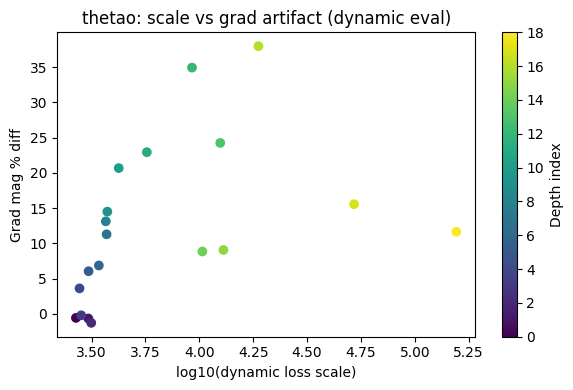

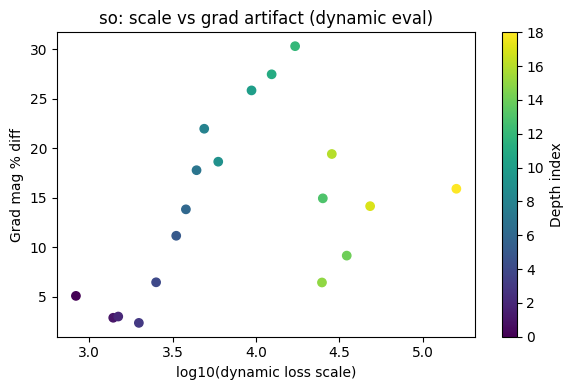

In [ ]:
# %%

def scatter_scale_vs_grad(var_prefix, grad_by_depth):
    xs, ys, depths = [], [], []
    for depth, grad in grad_by_depth.items():
        key = f"{var_prefix}_{depth}"
        if key in loss_scales:
            xs.append(math.log10(loss_scales[key]))
            ys.append(grad)
            depths.append(depth)
    plt.figure(figsize=(6, 4))
    plt.scatter(xs, ys, c=depths, cmap="viridis")
    plt.colorbar(label="Depth index")
    plt.xlabel("log10(dynamic loss scale)")
    plt.ylabel("Grad mag % diff")
    plt.title(f"{var_prefix}: scale vs grad artifact (dynamic eval)")
    plt.tight_layout()

scatter_scale_vs_grad("thetao", grad_thetao_dyn)
scatter_scale_vs_grad("so", grad_so_dyn)

# %% [markdown]

 ### 4) Caps reduce gradient artifacts and improve OHC metrics

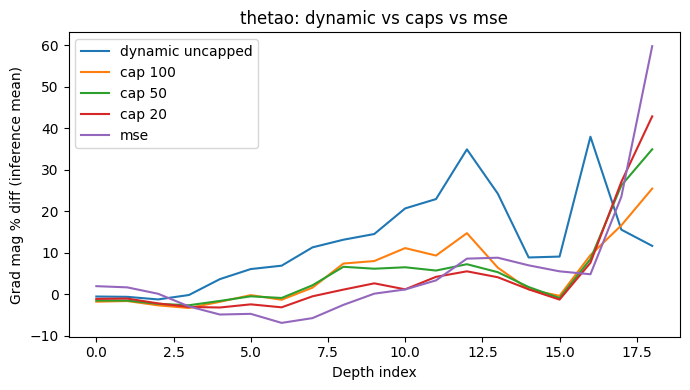

In [ ]:
# %%

def depth_profile_plot(var_prefix, label_to_run_key):
    plt.figure(figsize=(7, 4))
    for label, run_key in label_to_run_key.items():
        grad = extract_grad(runs[run_key], var_prefix)
        plt.plot(sorted(grad), [grad[k] for k in sorted(grad)], label=label)
    plt.xlabel("Depth index")
    plt.ylabel("Grad mag % diff (inference mean)")
    plt.title(f"{var_prefix}: dynamic vs caps vs mse")
    plt.legend()
    plt.tight_layout()


depth_profile_plot(
    "thetao",
    {
        "dynamic uncapped": "eval_dynamic_uncapped",
        "cap 100": "eval_cap_100",
        "cap 50": "eval_cap_50",
        "cap 20": "eval_cap_20",
        "mse": "eval_mse",
    },
)

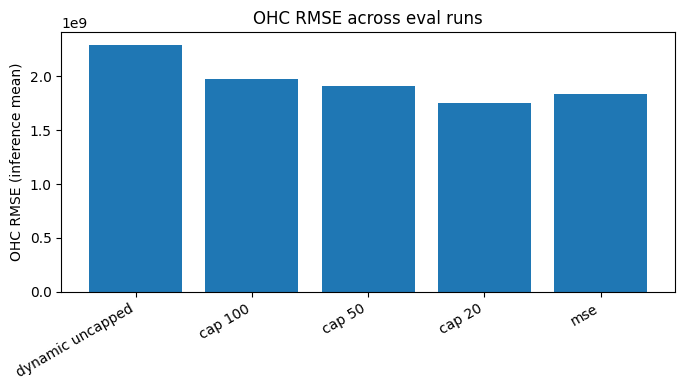

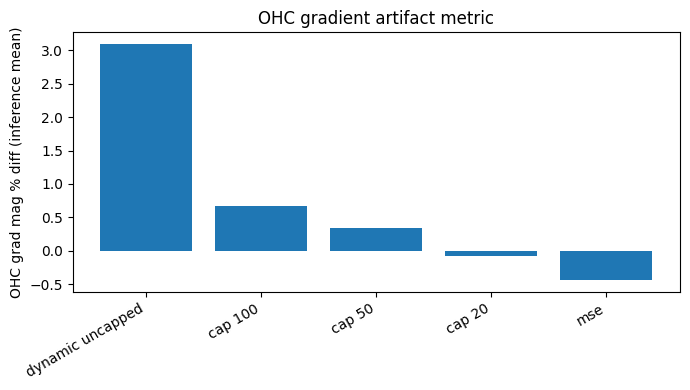

In [ ]:
# %%

ohc_rows = []
for label, key in [
    ("dynamic uncapped", "eval_dynamic_uncapped"),
    ("cap 100", "eval_cap_100"),
    ("cap 50", "eval_cap_50"),
    ("cap 20", "eval_cap_20"),
    ("mse", "eval_mse"),
]:
    m = extract_ohc_metrics(runs[key])
    ohc_rows.append((label, m))

labels = [r[0] for r in ohc_rows]
rmse = [r[1]["inference/mean/weighted_rmse/ocean_heat_content"] for r in ohc_rows]
grad = [r[1]["inference/mean/weighted_grad_mag_percent_diff/ocean_heat_content"] for r in ohc_rows]

plt.figure(figsize=(7, 4))
plt.bar(labels, rmse)
plt.ylabel("OHC RMSE (inference mean)")
plt.title("OHC RMSE across eval runs")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.figure(figsize=(7, 4))
plt.bar(labels, grad)
plt.ylabel("OHC grad mag % diff (inference mean)")
plt.title("OHC gradient artifact metric")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

# %% [markdown]

 ## Actions taken in codebase

 1) **DynamicLoss wet normalization bug fix**

 DynamicLoss now normalizes per-channel losses by wet fraction, so channels with smaller wet area no longer get artificially inflated weights.

 2) **New loss metric: `mse_area_weighted`**

 This computes area-weighted, wet-normalized MSE per channel (cos-lat weighting).

 3) **DynamicLoss can include gradient penalty**

 DynamicLoss now optionally composes GradientLoss (configurable via `loss.gradient`).

 Code references:
 - `src/ocean_emulators/utils/loss.py`
 - `src/ocean_emulators/config.py`

 ## How to enable new options

 **Area-weighted MSE**

 ```
 loss: mse_area_weighted
 ```

 or for dynamic:

 ```
 loss:
   type: dynamic
   metric: mse_area_weighted
 ```

 **Dynamic + gradient penalty**

 ```
 loss:
   type: dynamic
   metric: mse
   gradient:
     type: gradient
     alpha: 0.1
 ```

 ## Suggested next experiments

 - Re-run dynamic loss with the wet-normalization fix (uncapped, cap 50, cap 20).
 - Compare `mse_area_weighted` vs `mse` in both one-step validation and long rollouts.
 - Try dynamic+gradient penalty with a small alpha (e.g. 0.05–0.2) and look for reduction in banding.
 - Add a "banding score" diagnostic: zonal-mean error vs latitude and compute 1D power at narrow bands.
 - Track `train/loss_scale/channel/*` against `inference/mean/weighted_grad_mag_percent_diff/*` after each run to see if correlation weakens.